# Project: Query Optimization using delta tables and partitionning

**Data Source:** The data comes from kaggle and it is a collection of life expectancy % per countries based on the criterias that we are going to discuss below

It take a history of 15 years of data for 190 countries

# Homework


## Outline

This project is about building an effective data preparation pipeline.
It covers the following aspects:

* ingest raw data, curate it, transform it
* load the data into delta tables to enforce constraints and allow updates
* chose an optimal data layout to speedup query evaluation

It is based on raw data about life expectancy per countries from the world Health Organization.

We are going to understand the data and decide about a relevant analysis (2 or 3 analytical queries) that can be performed on this data.



## Prerequisite

### System setup

In [1]:
%%capture
!pip install pyspark==3.5.3
!pip install -q delta-spark==3.2.1
!pip install pyngrok

In [2]:
!pip list|grep spark

dataproc-spark-connect                   1.0.1
delta-spark                              3.2.1
pyspark                                  3.5.3


In [3]:
from pyspark import SparkConf
# from pyspark.context import SparkContext
from pyspark.sql import SparkSession

local = "local[*]"
appName = "Capstone project with Delta Lake  "
localConfig = SparkConf().setAppName(appName).setMaster(local).\
  set("spark.executor.memory", "8G").\
  set("spark.driver.memory","8G").\
  set("spark.sql.catalogImplementation","in-memory").\
  set("spark.sql.extensions","io.delta.sql.DeltaSparkSessionExtension").\
  set("spark.sql.catalog.spark_catalog","org.apache.spark.sql.delta.catalog.DeltaCatalog").\
  set("spark.jars.packages","io.delta:delta-spark_2.12:3.1.0").\
  set("spark.databricks.delta.schema.autoMerge.enabled","true")

spark = SparkSession.builder.config(conf = localConfig).getOrCreate()
sc = spark.sparkContext
sc.setLogLevel("ERROR")

In [4]:
spark

### Data import

In [5]:
%%capture
!wget --no-verbose https://nuage.lip6.fr/s/89BG8HD9r3iE693/download/MLData.tgz -O /tmp/MLData.tgz
!tar -xzvf /tmp/MLData.tgz  --directory /tmp/

In [6]:
!ls -hal /tmp/MLData

total 73M
drwxr-xr-x 2  501 staff 4.0K Jan  6  2022 .
drwxrwxrwt 1 root root  4.0K Jan 16 11:11 ..
-rw-r--r-- 1  501 staff  66M Jan  6  2022 autos.csv
-rw-r--r-- 1  501 staff  176 Jan  6  2022 ._loan.csv
-rw-r--r-- 1  501 staff 6.8M Jan  6  2022 loan.csv


In [7]:
query = """
CREATE TABLE IF NOT EXISTS lifeExpectancy
USING csv
OPTIONS (
  header "true",
  path "/content/Life Expectancy Data.csv",
  inferSchema "true"
)
"""
spark.sql(query)

DataFrame[]

## Phase 0: Understanding the data

In this part, you are invited to get some knowledge about the data by reading its schema and extracting  some basic statistical information about the values of columns that you will find interesting.

In [8]:
query = """
DESCRIBE lifeExpectancy
"""
spark.sql(query).show()

+--------------------+---------+-------+
|            col_name|data_type|comment|
+--------------------+---------+-------+
|             Country|   string|   NULL|
|                Year|      int|   NULL|
|              Status|   string|   NULL|
|    Life expectancy |   double|   NULL|
|     Adult Mortality|      int|   NULL|
|       infant deaths|      int|   NULL|
|             Alcohol|   double|   NULL|
|percentage expend...|   double|   NULL|
|         Hepatitis B|      int|   NULL|
|            Measles |      int|   NULL|
|                BMI |   double|   NULL|
|  under-five deaths |      int|   NULL|
|               Polio|      int|   NULL|
|   Total expenditure|   double|   NULL|
|         Diphtheria |      int|   NULL|
|            HIV/AIDS|   double|   NULL|
|                 GDP|   double|   NULL|
|          Population|   double|   NULL|
| thinness  1-19 y...|   double|   NULL|
|  thinness 5-9 years|   double|   NULL|
+--------------------+---------+-------+
only showing top

In [9]:
query = """
SELECT * FROM LifeExpectancy TABLESAMPLE (5 ROWS);
"""
spark.sql(query).show()


+-----------+----+----------+----------------+---------------+-------------+-------+----------------------+-----------+--------+-----+------------------+-----+-----------------+-----------+---------+----------+-----------+---------------------+-------------------+-------------------------------+---------+
|    Country|Year|    Status|Life expectancy |Adult Mortality|infant deaths|Alcohol|percentage expenditure|Hepatitis B|Measles | BMI |under-five deaths |Polio|Total expenditure|Diphtheria | HIV/AIDS|       GDP| Population| thinness  1-19 years| thinness 5-9 years|Income composition of resources|Schooling|
+-----------+----+----------+----------------+---------------+-------------+-------+----------------------+-----------+--------+-----+------------------+-----+-----------------+-----------+---------+----------+-----------+---------------------+-------------------+-------------------------------+---------+
|Afghanistan|2015|Developing|            65.0|            263|           62|   

In [10]:
query = """
SELECT *
FROM LifeExpectancy
TABLESAMPLE (1000 ROWS)
"""
small = spark.sql(query)


In [11]:
small.show(5)

+-----------+----+----------+----------------+---------------+-------------+-------+----------------------+-----------+--------+-----+------------------+-----+-----------------+-----------+---------+----------+-----------+---------------------+-------------------+-------------------------------+---------+
|    Country|Year|    Status|Life expectancy |Adult Mortality|infant deaths|Alcohol|percentage expenditure|Hepatitis B|Measles | BMI |under-five deaths |Polio|Total expenditure|Diphtheria | HIV/AIDS|       GDP| Population| thinness  1-19 years| thinness 5-9 years|Income composition of resources|Schooling|
+-----------+----+----------+----------------+---------------+-------------+-------+----------------------+-----------+--------+-----+------------------+-----+-----------------+-----------+---------+----------+-----------+---------------------+-------------------+-------------------------------+---------+
|Afghanistan|2015|Developing|            65.0|            263|           62|   

In [12]:
%%capture
! pip install ydata_profiling

In [13]:
from ydata_profiling import ProfileReport


In [14]:
# cars = spark.table('raw_vehiculePrices').cache()


In [15]:
expectancy_report = ProfileReport(small,
                title='expectancy',
                infer_dtypes=False,
                interactions=None,
                missing_diagrams=None,
                correlations=None)

In [16]:
expectancy_report

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

select all the columns with missing values less than 10%

## Phase 1: Cleaning the data and selecting relevant columns

In this part you are invited to decide which columns are useful for you analysis and to perform some cleaning on the data by removing outlier values (e.g. remove records with strange values for a specific column).
The result of your cleaning and selection should be stored in a table called `phase1`

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

house_df = pd.read_csv("/content/Life Expectancy Data.csv")
#Check again the correlation of the ocean proximity values with our target


In [18]:
house_df.shape

(2938, 22)

In [19]:
house_df.columns = house_df.columns.str.strip()
house_df.columns = house_df.columns.str.replace(' ', '_')


In [20]:
house_df.columns

Index(['Country', 'Year', 'Status', 'Life_expectancy', 'Adult_Mortality',
       'infant_deaths', 'Alcohol', 'percentage_expenditure', 'Hepatitis_B',
       'Measles', 'BMI', 'under-five_deaths', 'Polio', 'Total_expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness__1-19_years',
       'thinness_5-9_years', 'Income_composition_of_resources', 'Schooling'],
      dtype='object')

In [21]:
life_expectancy_df = house_df[["BMI","Country", "Status", "Adult_Mortality", "infant_deaths", "Life_expectancy", "Schooling", "HIV/AIDS","Year","Alcohol","Total_expenditure","Income_composition_of_resources"]]

<Axes: >

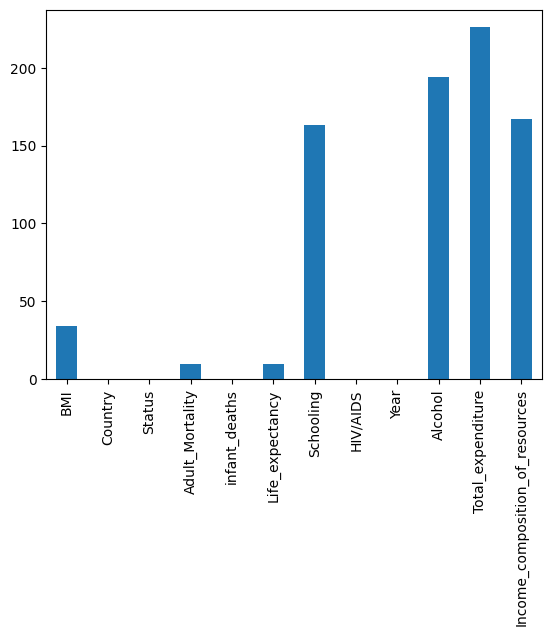

In [22]:
life_expectancy_df.isnull().sum().plot(kind='bar')

In [23]:
numeric_cols_with_nulls = [
    'BMI',
    'Adult_Mortality',
    'Life_expectancy',
    'Schooling',
    'Alcohol',
    'Total_expenditure',
    'Income_composition_of_resources'
]

for col_name in numeric_cols_with_nulls:
    if col_name in life_expectancy_df.columns:
        mean_value = life_expectancy_df[col_name].mean()
        life_expectancy_df[col_name].fillna(mean_value, inplace=True)

print("Null values after mean imputation:")
print(life_expectancy_df.isnull().sum())

Null values after mean imputation:
BMI                                0
Country                            0
Status                             0
Adult_Mortality                    0
infant_deaths                      0
Life_expectancy                    0
Schooling                          0
HIV/AIDS                           0
Year                               0
Alcohol                            0
Total_expenditure                  0
Income_composition_of_resources    0
dtype: int64


/tmp/ipython-input-2136000633.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  life_expectancy_df[col_name].fillna(mean_value, inplace=True)
/tmp/ipython-input-2136000633.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  life_expectancy_df[col_name].fillna(mean_value, inplace=True)


In [24]:
life_expectancy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   BMI                              2938 non-null   float64
 1   Country                          2938 non-null   object 
 2   Status                           2938 non-null   object 
 3   Adult_Mortality                  2938 non-null   float64
 4   infant_deaths                    2938 non-null   int64  
 5   Life_expectancy                  2938 non-null   float64
 6   Schooling                        2938 non-null   float64
 7   HIV/AIDS                         2938 non-null   float64
 8   Year                             2938 non-null   int64  
 9   Alcohol                          2938 non-null   float64
 10  Total_expenditure                2938 non-null   float64
 11  Income_composition_of_resources  2938 non-null   float64
dtypes: float64(8), int64

<Axes: >

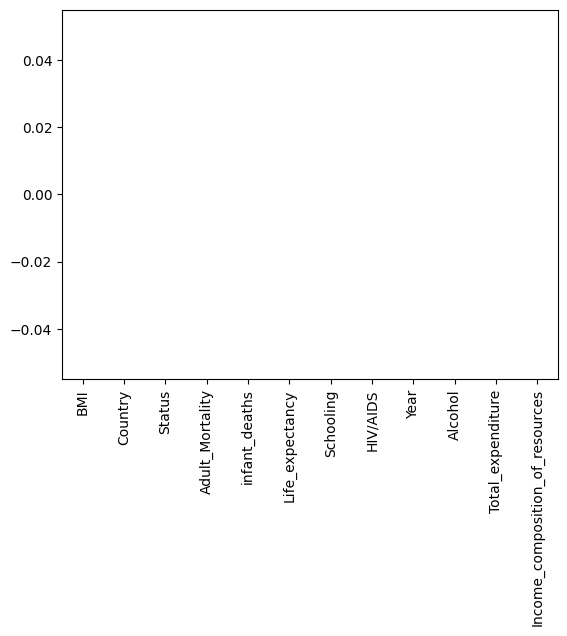

In [25]:
life_expectancy_df.isnull().sum().plot(kind='bar')

<Axes: >

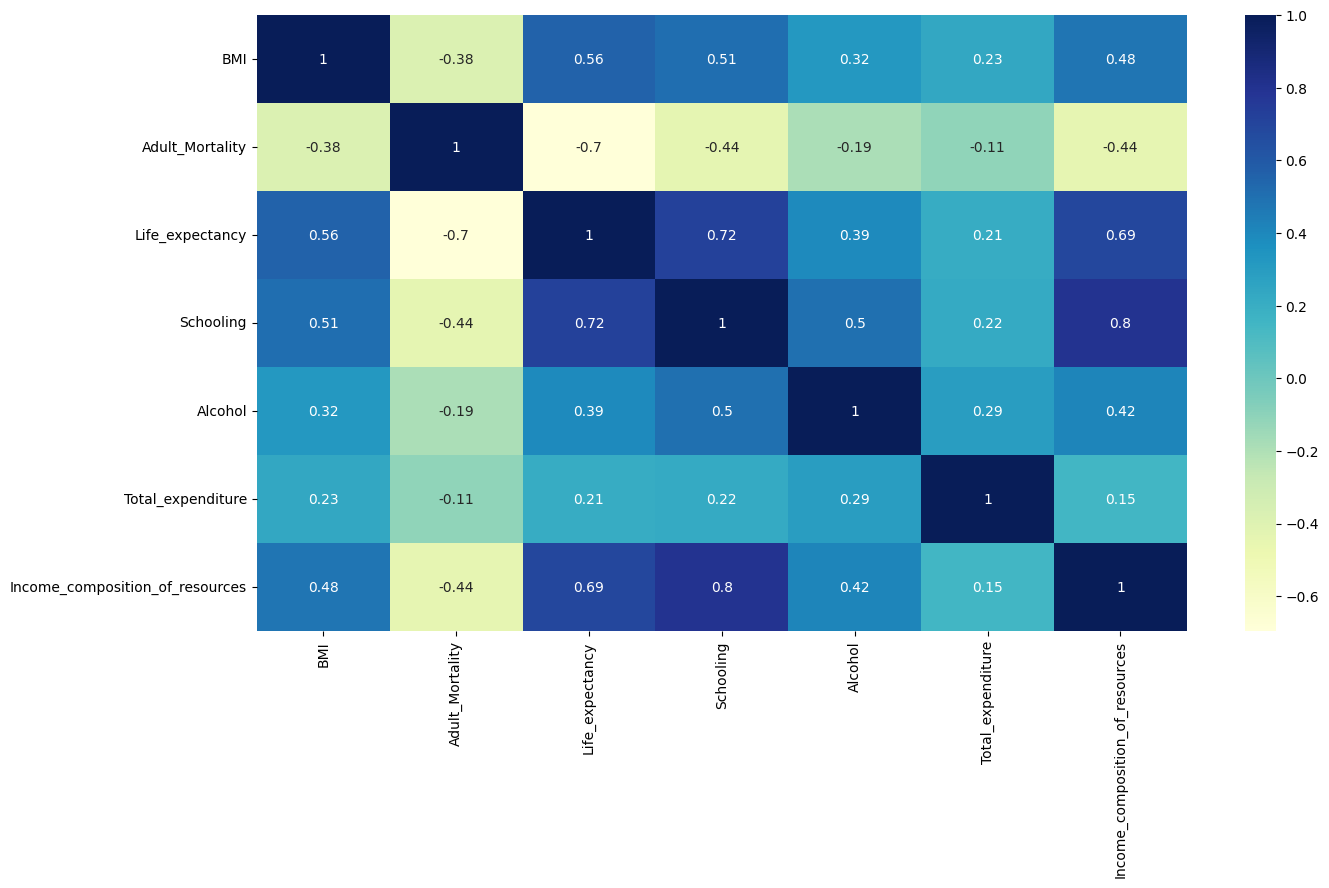

In [26]:
numeric_cols_with_nulls = [
    'BMI',
    'Adult_Mortality',
    'Life_expectancy',
    'Schooling',
    'Alcohol',
    'Total_expenditure',
    'Income_composition_of_resources'
]


plt.figure(figsize=(15,8))
sns.heatmap(life_expectancy_df[numeric_cols_with_nulls].corr(), annot=True, cmap="YlGnBu")

The correlation matrix was used to examine the relationships between the selected variables and life expectancy in order to justify their inclusion in the analysis. Overall, the results indicate that the chosen variables have meaningful associations with life expectancy and represent key health, socioeconomic, and lifestyle factors.

Adult mortality shows a strong negative correlation with life expectancy (−0.70), indicating that countries with higher adult mortality rates tend to have lower life expectancy. This strong relationship highlights adult mortality as an important health indicator and supports its inclusion as a core explanatory variable.

Schooling exhibits a strong positive correlation with life expectancy (0.72). This suggests that higher levels of education are associated with longer life expectancy, likely due to improved health awareness, better employment opportunities, and increased access to healthcare services. Additionally, schooling is highly correlated with income composition of resources (0.80), reflecting the close relationship between education and economic development.

Income composition of resources also shows a strong positive correlation with life expectancy (0.69). This indicates that countries with higher income levels generally experience better health outcomes, as greater economic resources allow for improved nutrition, healthcare access, and living conditions.

Body Mass Index (BMI) demonstrates a moderate positive correlation with life expectancy (0.56). In the context of cross-country analysis, this relationship may reflect better nutritional status and food availability, particularly in developing countries where low BMI can be associated with undernutrition.

Alcohol consumption shows a moderate positive correlation with life expectancy (0.39). While this does not imply a causal relationship, it may reflect broader socioeconomic and lifestyle factors, as countries with higher development levels often report both higher life expectancy and higher alcohol consumption.

Total health expenditure has a weaker but positive correlation with life expectancy (0.21). Although the relationship is not strong, it suggests that increased spending on health contributes positively to population health outcomes when considered alongside other factors.

In summary, the selected variables were included because they show statistically meaningful relationships with life expectancy and capture different dimensions of population health, including mortality, education, economic conditions, nutrition, lifestyle, and healthcare investment. Together, these variables provide a comprehensive framework for analyzing the determinants of life expectancy.

In [27]:
house_df.shape

(2938, 22)


## Phase 2: Organizing the data

In this part you are invited to load the data into delta tables where you will define meaningful constraints and conditions to be fulfiled by any future incoming data.
The result of this phase should a delta table called `deltaPrices`

In [28]:
life_expectancy_spark_df = spark.createDataFrame(life_expectancy_df)
life_expectancy_spark_df.printSchema()


root
 |-- BMI: double (nullable = true)
 |-- Country: string (nullable = true)
 |-- Status: string (nullable = true)
 |-- Adult_Mortality: double (nullable = true)
 |-- infant_deaths: long (nullable = true)
 |-- Life_expectancy: double (nullable = true)
 |-- Schooling: double (nullable = true)
 |-- HIV/AIDS: double (nullable = true)
 |-- Year: long (nullable = true)
 |-- Alcohol: double (nullable = true)
 |-- Total_expenditure: double (nullable = true)
 |-- Income_composition_of_resources: double (nullable = true)



**Adding  constraints**



In [29]:
# Create the Delta table 'life_expectancy_delta' from the Spark DataFrame
life_expectancy_spark_df.write.format("delta").mode("overwrite").saveAsTable("life_expectancy_delta")

# Add constraints to the 'life_expectancy_delta' table

# 1. NOT NULL constraints for essential columns
# Ensure that the 'Country' column, which identifies the country, is never null.
spark.sql("ALTER TABLE life_expectancy_delta ADD CONSTRAINT country_not_null CHECK (Country IS NOT NULL)")
# Ensure that the 'Year' column, representing the year of observation, is never null.
spark.sql("ALTER TABLE life_expectancy_delta ADD CONSTRAINT year_not_null CHECK (Year IS NOT NULL)")
# Ensure that 'Life_expectancy', the target variable, is always present.
spark.sql("ALTER TABLE life_expectancy_delta ADD CONSTRAINT life_expectancy_not_null CHECK (Life_expectancy IS NOT NULL)")
# Ensure that 'Adult_Mortality' figures are always available.
spark.sql("ALTER TABLE life_expectancy_delta ADD CONSTRAINT adult_mortality_not_null CHECK (Adult_Mortality IS NOT NULL)")

spark.sql("ALTER TABLE life_expectancy_delta ADD CONSTRAINT Status_check CHECK (Status == 'Developing' OR Status == 'Developed')")
# 2. CHECK constraints for data validity
# Life expectancy should always be a positive value.
spark.sql("ALTER TABLE life_expectancy_delta ADD CONSTRAINT life_expectancy_positive CHECK (Life_expectancy > 0)")
# Years should be within a reasonable range (e.g., after 1900 and up to the current year).
spark.sql("ALTER TABLE life_expectancy_delta ADD CONSTRAINT year_valid_range CHECK (Year >= 1900 AND Year <= 2024)")
# Adult mortality cannot be a negative value.
spark.sql("ALTER TABLE life_expectancy_delta ADD CONSTRAINT adult_mortality_non_negative CHECK (Adult_Mortality >= 0)")
# Infant deaths cannot be a negative value.
spark.sql("ALTER TABLE life_expectancy_delta ADD CONSTRAINT infant_deaths_non_negative CHECK (infant_deaths >= 0)")
# Schooling years cannot be negative.
spark.sql("ALTER TABLE life_expectancy_delta ADD CONSTRAINT schooling_non_negative CHECK (Schooling >= 0)")
# HIV/AIDS prevalence rate cannot be negative.
spark.sql("ALTER TABLE life_expectancy_delta ADD CONSTRAINT hiv_aids_non_negative CHECK (`HIV/AIDS` >= 0)")
# Alcohol consumption cannot be negative.
spark.sql("ALTER TABLE life_expectancy_delta ADD CONSTRAINT alcohol_non_negative CHECK (Alcohol >= 0)")
# Total expenditure cannot be negative.
spark.sql("ALTER TABLE life_expectancy_delta ADD CONSTRAINT total_expenditure_non_negative CHECK (Total_expenditure >= 0)")
# Income composition of resources is typically a normalized score between 0 and 1.
spark.sql("ALTER TABLE life_expectancy_delta ADD CONSTRAINT income_composition_valid_range CHECK (Income_composition_of_resources >= 0 AND Income_composition_of_resources <= 1)")


print("Delta table 'life_expectancy_delta' created with specified constraints.")

# To verify constraints (optional, for debugging/information)
spark.sql("DESCRIBE DETAIL life_expectancy_delta").show(truncate=False)
spark.sql("SELECT * FROM life_expectancy_delta").limit(5).show()
spark.sql("SELECT COUNT(*) AS total_rows FROM life_expectancy_delta").show()


Delta table 'life_expectancy_delta' created with specified constraints.
+------+------------------------------------+-------------------------------------------+-----------+---------------------------------------------------+----------------------+-----------------------+----------------+--------+-----------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

The constraints added to the life_expectancy_delta table serve to ensure data quality and integrity. I've included NOT NULL constraints for critical columns like 'Country', 'Year', 'Life_expectancy', and 'Adult_Mortality' to prevent missing essential information. Additionally, CHECK constraints were applied to enforce valid data ranges and non-negative values for various numerical columns, such as ensuring 'Life_expectancy' is positive, 'Year' is within a realistic range, and 'Income_composition_of_resources' is between 0 and 1. These constraints are crucial for maintaining a reliable dataset for accurate analysis.

## Phase 3: Analysing the data and ensuring query evaluation efficiency

Suggest 2 or 3 meaningfull queries as described above and suggest a data organization scheme for optimizing one such query of your choice.

### Meaningful Queries for `life_expectancy_delta`

Here are three queries designed to extract insights from the `life_expectancy_delta` table:

#### Query 1: Average Life Expectancy Trend by Status Over Years
This query calculates the average life expectancy for each year, categorized by the development status of the country (Developing/Developed). It helps to observe the evolution of life expectancy and potential disparities between different country statuses over time.

In [30]:
import time
start_time = time.time()
query_1 = """
SELECT
  Year,
  Status,
  AVG(Life_expectancy) AS Average_Life_Expectancy
FROM
  life_expectancy_delta
GROUP BY
  Year,
  Status
ORDER BY
  Year,
  Status;
"""

spark.sql(query_1).show()
end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")

+----+----------+-----------------------+
|Year|    Status|Average_Life_Expectancy|
+----+----------+-----------------------+
|2000| Developed|              76.803125|
|2000|Developing|       64.6198675496689|
|2001| Developed|      77.12812500000001|
|2001|Developing|      65.00993377483445|
|2002| Developed|              77.546875|
|2002|Developing|      65.19072847682119|
|2003| Developed|              77.940625|
|2003|Developing|      65.20662251655627|
|2004| Developed|              78.384375|
|2004|Developing|      65.37086092715232|
|2005| Developed|      78.59062499999999|
|2005|Developing|      66.00927152317881|
|2006| Developed|               79.13125|
|2006|Developing|       66.4503311258278|
|2007| Developed|      79.30000000000001|
|2007|Developing|       66.8609271523179|
|2008| Developed|               78.93125|
|2008|Developing|      67.41390728476819|
|2009| Developed|              79.584375|
|2009|Developing|      67.89403973509935|
+----+----------+-----------------

In [31]:
spark.sql(query_1).explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [Year#31524L ASC NULLS FIRST, Status#31518 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(Year#31524L ASC NULLS FIRST, Status#31518 ASC NULLS FIRST, 200), ENSURE_REQUIREMENTS, [plan_id=15266]
      +- HashAggregate(keys=[Year#31524L, Status#31518], functions=[avg(Life_expectancy#31521)])
         +- Exchange hashpartitioning(Year#31524L, Status#31518, 200), ENSURE_REQUIREMENTS, [plan_id=15263]
            +- HashAggregate(keys=[Year#31524L, Status#31518], functions=[partial_avg(Life_expectancy#31521)])
               +- FileScan parquet spark_catalog.default.life_expectancy_delta[Status#31518,Life_expectancy#31521,Year#31524L] Batched: true, DataFilters: [], Format: Parquet, Location: PreparedDeltaFileIndex(1 paths)[file:/content/spark-warehouse/life_expectancy_delta], PartitionFilters: [], PushedFilters: [], ReadSchema: struct<Status:string,Life_expectancy:double,Year:bigint>




#### Query 2: Top 10 Countries with the Highest Life Expectancy in the Latest Year
This query identifies the countries with the highest life expectancy in the most recent year available in the dataset. It provides a snapshot of the top performers in terms of health and development.

In [32]:
query_2 = """
WITH LatestYear AS (
  SELECT
    MAX(Year) AS Max_Year
  FROM
    life_expectancy_delta
)
SELECT
  t1.Country,
  t1.Life_expectancy
FROM
  life_expectancy_delta AS t1
JOIN
  LatestYear AS t2
ON
  t1.Year = t2.Max_Year
ORDER BY
  t1.Life_expectancy DESC
LIMIT 10;
"""

spark.sql(query_2).show()

+-----------+---------------+
|    Country|Life_expectancy|
+-----------+---------------+
|   Slovenia|           88.0|
|    Denmark|           86.0|
|     Cyprus|           85.0|
|      Chile|           85.0|
|      Japan|           83.7|
|Switzerland|           83.4|
|  Singapore|           83.1|
|  Australia|           82.8|
|      Spain|           82.8|
|    Iceland|           82.7|
+-----------+---------------+



In [33]:
spark.sql(query_2).explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- TakeOrderedAndProject(limit=10, orderBy=[Life_expectancy#31940 DESC NULLS LAST], output=[Country#31936,Life_expectancy#31940])
   +- Project [Country#31936, Life_expectancy#31940]
      +- BroadcastHashJoin [Year#31943L], [Max_Year#31922L], Inner, BuildRight, false
         :- Filter isnotnull(Year#31943L)
         :  +- FileScan parquet spark_catalog.default.life_expectancy_delta[Country#31936,Life_expectancy#31940,Year#31943L] Batched: true, DataFilters: [isnotnull(Year#31943L)], Format: Parquet, Location: PreparedDeltaFileIndex(1 paths)[file:/content/spark-warehouse/life_expectancy_delta], PartitionFilters: [], PushedFilters: [IsNotNull(Year)], ReadSchema: struct<Country:string,Life_expectancy:double,Year:bigint>
         +- BroadcastExchange HashedRelationBroadcastMode(List(input[0, bigint, true]),false), [plan_id=15528]
            +- LocalTableScan [Max_Year#31922L]




#### Query 3: Correlation between Life Expectancy, Adult Mortality, and Schooling
This query calculates the average life expectancy, adult mortality, and schooling years for each country. It can help in understanding the general relationship between these key indicators, although a full correlation analysis would require statistical functions or a separate analytical step.

In [34]:
query_3 = """
SELECT
  Country,
  AVG(Life_expectancy) AS Avg_Life_Expectancy,
  AVG(Adult_Mortality) AS Avg_Adult_Mortality,
  AVG(Schooling) AS Avg_Schooling
FROM
  life_expectancy_delta
GROUP BY
  Country
ORDER BY
  Avg_Life_expectancy DESC;
"""

spark.sql(query_3).show()

+--------------------+-------------------+-------------------+------------------+
|             Country|Avg_Life_Expectancy|Avg_Adult_Mortality|     Avg_Schooling|
+--------------------+-------------------+-------------------+------------------+
|               Japan|            82.5375|             57.125|            14.975|
|              Sweden|           82.51875|            59.1875|15.868750000000002|
|             Iceland|  82.44375000000001|             49.375|18.156250000000004|
|         Switzerland|           82.33125|              55.75|15.393749999999997|
|              France|           82.21875|             73.125|15.899999999999999|
|               Italy|            82.1875|            54.1875|          15.93125|
|               Spain|           82.06875|             63.625|          16.35625|
|           Australia|  81.81250000000001|            63.1875|           20.0375|
|              Norway|           81.79375|              66.25|          17.46875|
|              C

In [35]:
spark.sql(query_3).explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [Avg_Life_expectancy#32362 DESC NULLS LAST], true, 0
   +- Exchange rangepartitioning(Avg_Life_expectancy#32362 DESC NULLS LAST, 200), ENSURE_REQUIREMENTS, [plan_id=15656]
      +- HashAggregate(keys=[Country#32366], functions=[avg(Life_expectancy#32370), avg(Adult_Mortality#32368), avg(Schooling#32371)])
         +- Exchange hashpartitioning(Country#32366, 200), ENSURE_REQUIREMENTS, [plan_id=15653]
            +- HashAggregate(keys=[Country#32366], functions=[partial_avg(Life_expectancy#32370), partial_avg(Adult_Mortality#32368), partial_avg(Schooling#32371)])
               +- FileScan parquet spark_catalog.default.life_expectancy_delta[Country#32366,Adult_Mortality#32368,Life_expectancy#32370,Schooling#32371] Batched: true, DataFilters: [], Format: Parquet, Location: PreparedDeltaFileIndex(1 paths)[file:/content/spark-warehouse/life_expectancy_delta], PartitionFilters: [], PushedFilters: [], ReadSchema: struct<Country:s

# Partitioning and Optimization

In [36]:
life_expectancy_spark_df.write.format("delta").mode("overwrite").partitionBy("Year").saveAsTable("life_expectancy_delta_by_year")

In [37]:
spark.sql("SELECT COUNT(*) AS total_rows FROM life_expectancy_delta_by_year").show()

+----------+
|total_rows|
+----------+
|      2938|
+----------+



In [38]:
import time
start_time = time.time()
query_1 = """
SELECT
  Year,
  Status,
  Country,
  AVG(Life_expectancy) AS Average_Life_Expectancy
FROM
  life_expectancy_delta Where Country = 'Cameroon'
GROUP BY
  Year,
  Status,
  Country
ORDER BY
  Year,
  Status;
"""

spark.sql(query_1).show()
end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")

+----+----------+--------+-----------------------+
|Year|    Status| Country|Average_Life_Expectancy|
+----+----------+--------+-----------------------+
|2000|Developing|Cameroon|                   51.4|
|2001|Developing|Cameroon|                   51.5|
|2002|Developing|Cameroon|                   51.6|
|2003|Developing|Cameroon|                   51.8|
|2004|Developing|Cameroon|                   52.1|
|2005|Developing|Cameroon|                   52.8|
|2006|Developing|Cameroon|                   53.3|
|2007|Developing|Cameroon|                   53.6|
|2008|Developing|Cameroon|                   54.2|
|2009|Developing|Cameroon|                   54.8|
|2010|Developing|Cameroon|                   55.3|
|2011|Developing|Cameroon|                   55.6|
|2012|Developing|Cameroon|                   55.9|
|2013|Developing|Cameroon|                   56.4|
|2014|Developing|Cameroon|                   56.7|
|2015|Developing|Cameroon|                   57.3|
+----+----------+--------+-----

In [39]:
spark.sql(query_1).explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [Year#33897L ASC NULLS FIRST, Status#33891 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(Year#33897L ASC NULLS FIRST, Status#33891 ASC NULLS FIRST, 200), ENSURE_REQUIREMENTS, [plan_id=16002]
      +- HashAggregate(keys=[Year#33897L, Status#33891, Country#33890], functions=[avg(Life_expectancy#33894)])
         +- Exchange hashpartitioning(Year#33897L, Status#33891, Country#33890, 200), ENSURE_REQUIREMENTS, [plan_id=15999]
            +- HashAggregate(keys=[Year#33897L, Status#33891, Country#33890], functions=[partial_avg(Life_expectancy#33894)])
               +- Filter (isnotnull(Country#33890) AND (Country#33890 = Cameroon))
                  +- FileScan parquet spark_catalog.default.life_expectancy_delta[Country#33890,Status#33891,Life_expectancy#33894,Year#33897L] Batched: true, DataFilters: [isnotnull(Country#33890), (Country#33890 = Cameroon)], Format: Parquet, Location: PreparedDeltaFileIndex(1 paths)[f

## Ingesting new data and reruning analytics  

In this part you are invited to suggest the insertion of fictious new data that conforms to the schema established in phase 2 and to rerun some queries of phase 3 to see the evolution of the result. Ideally, write a query that compares an aggregation value in two different versions of the data by exploiting the delta history feature.

In [40]:
data = [
    (120.0, 'Ghana', 'Developing', 400.0, 300, 17.0, 46.0, 0.01, 2024, 4.02, 500.0, 0.7),
    (85.5,  'Nigeria', 'Developing', 350.0, 250, 54.3, 10.2, 0.02, 2023, 3.10, 420.0, 0.5),
    (60.2,  'Kenya', 'Developing', 280.0, 180, 62.7, 12.8, 0.015, 2022, 2.50, 390.0, 0.6),
    (72.0,  'South Africa', 'Developing', 410.0, 220, 64.1, 13.5, 0.12, 2021, 5.80, 600.0, 0.5),
    (25.4,  'Germany', 'Developed', 95.0,  3,   81.2, 16.8, 0.001, 2020, 11.6, 820.0, 0.4)
]

columns = [
    "BMI", "Country", "Status", "Adult_Mortality", "infant_deaths",
    "Life_expectancy", "Schooling", "HIV/AIDS", "Year",
    "Alcohol", "Total_expenditure", "Income_composition_of_resources"
]

df = spark.createDataFrame(data, columns)
df.write.format("delta").mode("append").saveAsTable("life_expectancy_delta_by_year")


In [41]:
spark.sql("SELECT COUNT(*) AS total_rows FROM life_expectancy_delta_by_year").show()


+----------+
|total_rows|
+----------+
|      2943|
+----------+



In [47]:
import time
start_time = time.time()
query_1 = """
SELECT
  Year,
  Status,
  Country,
  AVG(Life_expectancy) AS Average_Life_Expectancy
FROM
  life_expectancy_delta Where Country = 'Cameroon' and Year = 2015
GROUP BY
  Year,
  Status,
  Country
ORDER BY
  Year,
  Status;
"""

spark.sql(query_1).show()
end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")

+----+----------+--------+-----------------------+
|Year|    Status| Country|Average_Life_Expectancy|
+----+----------+--------+-----------------------+
|2015|Developing|Cameroon|                   57.3|
+----+----------+--------+-----------------------+

Execution time: 1.9721474647521973 seconds


In [49]:
spark.sql(query_1).explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [Year#35968L ASC NULLS FIRST, Status#35962 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(Year#35968L ASC NULLS FIRST, Status#35962 ASC NULLS FIRST, 200), ENSURE_REQUIREMENTS, [plan_id=16696]
      +- HashAggregate(keys=[Year#35968L, Status#35962, Country#35961], functions=[avg(Life_expectancy#35965)])
         +- Exchange hashpartitioning(Year#35968L, Status#35962, Country#35961, 200), ENSURE_REQUIREMENTS, [plan_id=16693]
            +- HashAggregate(keys=[Year#35968L, Status#35962, Country#35961], functions=[partial_avg(Life_expectancy#35965)])
               +- Filter (((isnotnull(Country#35961) AND isnotnull(Year#35968L)) AND (Country#35961 = Cameroon)) AND (Year#35968L = 2015))
                  +- FileScan parquet spark_catalog.default.life_expectancy_delta[Country#35961,Status#35962,Life_expectancy#35965,Year#35968L] Batched: true, DataFilters: [isnotnull(Country#35961), isnotnull(Year#35968L), (Country#

In [48]:
import time
start_time = time.time()
query_1 = """
SELECT
  Year,
  Status,
  Country,
  AVG(Life_expectancy) AS Average_Life_Expectancy
FROM
  life_expectancy_delta Where Country = 'Cameroon' and Year = 2015
GROUP BY
  Year,
  Status,
  Country
ORDER BY
  Year,
  Status;
"""

spark.sql(query_1).show()
end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")

+----+----------+--------+-----------------------+
|Year|    Status| Country|Average_Life_Expectancy|
+----+----------+--------+-----------------------+
|2015|Developing|Cameroon|                   57.3|
+----+----------+--------+-----------------------+

Execution time: 0.9640755653381348 seconds


In [45]:
spark.sql(query_1).explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [Year#35505L ASC NULLS FIRST, Status#35499 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(Year#35505L ASC NULLS FIRST, Status#35499 ASC NULLS FIRST, 200), ENSURE_REQUIREMENTS, [plan_id=16438]
      +- HashAggregate(keys=[Year#35505L, Status#35499, Country#35498], functions=[avg(Life_expectancy#35502)])
         +- Exchange hashpartitioning(Year#35505L, Status#35499, Country#35498, 200), ENSURE_REQUIREMENTS, [plan_id=16435]
            +- HashAggregate(keys=[Year#35505L, Status#35499, Country#35498], functions=[partial_avg(Life_expectancy#35502)])
               +- Filter (isnotnull(Country#35498) AND (Country#35498 = Cameroon))
                  +- FileScan parquet spark_catalog.default.life_expectancy_delta_by_year[Country#35498,Status#35499,Life_expectancy#35502,Year#35505L] Batched: true, DataFilters: [isnotnull(Country#35498), (Country#35498 = Cameroon)], Format: Parquet, Location: PreparedDeltaFileIndex(1 